# Heart Rate Zones Detection and Visualization

This notebook contains functions for:
1. Detecting VT1 (Ventilatory Threshold 1) - the crossover point where carbohydrate burning exceeds fat burning
2. Detecting VT2 (Ventilatory Threshold 2) - the respiratory compensation point where ventilation increases sharply
3. Calculating personalized heart rate zones based on VT1 and VT2
4. Visualizing heart rate zones in a table format

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Dict, Tuple, Any

## VT1 and VT2 Detection Functions

**VT1 (Ventilatory Threshold 1 / Aerobic Threshold):**
- The point where carbohydrate oxidation begins to exceed fat oxidation
- Marks the transition from primarily aerobic metabolism to increased reliance on anaerobic pathways
- Typically occurs at 50-65% of VO2max

**VT2 (Ventilatory Threshold 2 / Anaerobic Threshold):**
- The point where ventilation increases disproportionately relative to oxygen consumption
- Detected via the inflection point in the ventilation (VE) or breathing frequency (BF) curve
- Typically occurs at 80-90% of VO2max

In [2]:
def detect_vt1(
    df: pd.DataFrame, 
    fat_col: str = "FAT_smoothed", 
    carb_col: str = "CHO_smoothed",
    hr_col: str = "HR(bpm)_smoothed",
    speed_col: str = "Speed",
    time_col: str = "T(sec)"
) -> Optional[Dict[str, Any]]:
    """
    Detect VT1 (Ventilatory Threshold 1) as the first point where carbohydrate 
    burning exceeds fat burning and remains higher for the rest of the test.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing metabolic data with fat and carbohydrate columns
    fat_col : str
        Column name for fat burn rate (smoothed recommended)
    carb_col : str
        Column name for carbohydrate burn rate (smoothed recommended)
    hr_col : str
        Column name for heart rate
    speed_col : str
        Column name for speed
    time_col : str
        Column name for time in seconds
        
    Returns
    -------
    dict or None
        Dictionary containing VT1 metrics:
        - HeartRate: HR at VT1
        - Speed: Speed at VT1
        - Time: Time at VT1
        - Index: DataFrame index at VT1
        Returns None if no crossover is found.
    """
    # Check if required columns exist
    for col in [fat_col, carb_col, hr_col]:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in DataFrame. Available columns: {df.columns.tolist()}")
    
    # Find where carbs exceed fat
    condition = df[carb_col] > df[fat_col]
    crossover_indices = condition[condition].index

    if len(crossover_indices) == 0:
        return None  # No crossover found
    
    # Find first crossover where carbs remain higher for the rest of the test
    for idx in crossover_indices:
        remaining_data = df.loc[idx:]
        if all(remaining_data[carb_col] > remaining_data[fat_col]):
            return {
                "HeartRate": df.loc[idx, hr_col],
                "Speed": df.loc[idx, speed_col] if speed_col in df.columns else None,
                "Time": df.loc[idx, time_col] if time_col in df.columns else None,
                "Index": idx
            }
    
    # If no sustained crossover, return the first crossover
    first_idx = crossover_indices[0]
    return {
        "HeartRate": df.loc[first_idx, hr_col],
        "Speed": df.loc[first_idx, speed_col] if speed_col in df.columns else None,
        "Time": df.loc[first_idx, time_col] if time_col in df.columns else None,
        "Index": first_idx
    }


def detect_vt2(
    df: pd.DataFrame, 
    vent_col: str = "VE(l/min)_smoothed", 
    bf_col: str = "BF(bpm)_smoothed",
    hr_col: str = "HR(bpm)_smoothed",
    speed_col: str = "Speed",
    time_col: str = "T(sec)",
    smooth_window: int = 5
) -> Optional[Dict[str, Any]]:
    """
    Detect VT2 (Ventilatory Threshold 2) using the slope/inflection method.
    
    VT2 is identified as the point where ventilation (or breathing frequency) 
    shows the largest acceleration (inflection point), indicating the respiratory 
    compensation point.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing metabolic data
    vent_col : str
        Column name for ventilation (VE) - preferred
    bf_col : str
        Column name for breathing frequency (BF) - fallback
    hr_col : str
        Column name for heart rate
    speed_col : str
        Column name for speed
    time_col : str
        Column name for time in seconds
    smooth_window : int
        Window size for additional smoothing of derivatives
        
    Returns
    -------
    dict or None
        Dictionary containing VT2 metrics:
        - HeartRate: HR at VT2
        - Speed: Speed at VT2
        - Time: Time at VT2
        - Index: DataFrame index at VT2
        Returns None if detection fails.
    """
    # Use ventilation column if available, otherwise use breathing frequency
    if vent_col in df.columns:
        col = vent_col
    elif bf_col in df.columns:
        col = bf_col
    else:
        raise ValueError(f"Neither '{vent_col}' nor '{bf_col}' found in DataFrame")
    
    # Create a copy to avoid modifying original
    df_copy = df.copy()
    
    # Compute first derivative (slope)
    df_copy["slope"] = df_copy[col].diff()
    
    # Optional: smooth the slope
    if smooth_window > 1:
        df_copy["slope"] = df_copy["slope"].rolling(window=smooth_window, center=True).mean()
    
    # Compute second derivative (acceleration/inflection)
    df_copy["second_derivative"] = df_copy["slope"].diff()
    
    # Find the index of maximum acceleration (inflection point)
    # Only consider positive values (actual increases in slope)
    positive_accel = df_copy["second_derivative"] > 0
    if not positive_accel.any():
        return None
        
    inflection_idx = df_copy.loc[positive_accel, "second_derivative"].idxmax()
    
    if pd.isna(inflection_idx):
        return None
    
    return {
        "HeartRate": df.loc[inflection_idx, hr_col],
        "Speed": df.loc[inflection_idx, speed_col] if speed_col in df.columns else None,
        "Time": df.loc[inflection_idx, time_col] if time_col in df.columns else None,
        "Index": inflection_idx
    }


def analyze_thresholds(
    df: pd.DataFrame,
    fat_col: str = "FAT_smoothed",
    carb_col: str = "CHO_smoothed",
    vent_col: str = "VE(l/min)_smoothed",
    bf_col: str = "BF(bpm)_smoothed",
    hr_col: str = "HR(bpm)_smoothed",
    speed_col: str = "Speed",
    time_col: str = "T(sec)"
) -> Tuple[Optional[Dict[str, Any]], Optional[Dict[str, Any]]]:
    """
    Analyze metabolic data to detect both VT1 and VT2 thresholds.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing metabolic test data
    fat_col, carb_col : str
        Column names for fat and carb burn rates
    vent_col, bf_col : str
        Column names for ventilation and breathing frequency
    hr_col, speed_col, time_col : str
        Column names for heart rate, speed, and time
        
    Returns
    -------
    tuple
        (vt1_dict, vt2_dict) - dictionaries containing threshold data
    """
    vt1 = detect_vt1(
        df, 
        fat_col=fat_col, 
        carb_col=carb_col,
        hr_col=hr_col,
        speed_col=speed_col,
        time_col=time_col
    )
    
    vt2 = detect_vt2(
        df,
        vent_col=vent_col,
        bf_col=bf_col,
        hr_col=hr_col,
        speed_col=speed_col,
        time_col=time_col
    )
    
    return vt1, vt2

## Zone Calculation Functions

Heart rate zones are calculated based on:
- **Zone 1 (Active Recovery):** Below optimal fat burning zone
- **Zone 2 (Aerobic Base/Fat Burning):** From optimal fat burning to VT1
- **Zone 3 (Aerobic Fitness):** From VT1 to approaching VT2
- **Zone 4 (Lactate Threshold):** Around VT2
- **Zone 5 (VO2 Max):** Above VT2

In [3]:
def find_optimal_fat_burning_zone(
    df: pd.DataFrame,
    fat_col: str = "FAT_smoothed",
    carb_col: str = "CHO_smoothed",
    hr_col: str = "HR(bpm)_smoothed",
    speed_col: str = "Speed",
    time_col: str = "T(sec)"
) -> Dict[str, Any]:
    """
    Find the optimal fat burning zone - the point with the highest fat:carb ratio.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing metabolic data
    fat_col : str
        Column name for fat burn rate
    carb_col : str
        Column name for carbohydrate burn rate
    hr_col : str
        Column name for heart rate
    speed_col : str
        Column name for speed
    time_col : str
        Column name for time
        
    Returns
    -------
    dict
        Dictionary containing optimal fat burning zone data:
        - HeartRate: HR at optimal fat burning
        - Speed: Speed at optimal fat burning
        - Time: Time at optimal fat burning
        - FatBurnRate: Fat burn rate at this point
        - CarbBurnRate: Carb burn rate at this point
        - FatCarbRatio: Ratio of fat to carb burning
        - Index: DataFrame index
    """
    # Calculate fat:carb ratio (add small value to avoid division by zero)
    df_copy = df.copy()
    df_copy['fat_carb_ratio'] = df_copy[fat_col] / (df_copy[carb_col] + 1e-8)
    
    # Find index of maximum ratio
    optimal_idx = df_copy['fat_carb_ratio'].idxmax()
    optimal_row = df_copy.loc[optimal_idx]
    
    return {
        "HeartRate": optimal_row[hr_col],
        "Speed": optimal_row.get(speed_col),
        "Time": optimal_row.get(time_col),
        "FatBurnRate": optimal_row[fat_col],
        "CarbBurnRate": optimal_row[carb_col],
        "FatCarbRatio": optimal_row['fat_carb_ratio'],
        "Index": optimal_idx
    }


def calculate_heart_rate_zones(
    df: pd.DataFrame,
    vt1: Optional[Dict[str, Any]] = None,
    vt2: Optional[Dict[str, Any]] = None,
    optimal_fat: Optional[Dict[str, Any]] = None,
    hr_max: Optional[float] = None,
    zone_5_buffer: float = 10.0
) -> Dict[str, Tuple[float, float]]:
    """
    Calculate personalized heart rate zones based on VT1, VT2, and optimal fat burning.
    
    If VT1/VT2/optimal_fat are not provided, they will be calculated from the DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing metabolic data
    vt1 : dict, optional
        VT1 data from detect_vt1()
    vt2 : dict, optional
        VT2 data from detect_vt2()
    optimal_fat : dict, optional
        Optimal fat burning data from find_optimal_fat_burning_zone()
    hr_max : float, optional
        Maximum heart rate achieved. If None, calculated from data.
    zone_5_buffer : float
        Buffer above VT2 heart rate for Zone 5 upper limit
        
    Returns
    -------
    dict
        Dictionary with zone names as keys and (start_hr, end_hr) tuples as values
    """
    # Calculate missing thresholds if not provided
    if optimal_fat is None:
        optimal_fat = find_optimal_fat_burning_zone(df)
    
    if vt1 is None:
        vt1 = detect_vt1(df)
    
    if vt2 is None:
        vt2 = detect_vt2(df)
    
    # Get heart rate values
    optimal_fat_hr = optimal_fat["HeartRate"]
    vt1_hr = vt1["HeartRate"] if vt1 else optimal_fat_hr + 15
    vt2_hr = vt2["HeartRate"] if vt2 else vt1_hr + 20
    
    # Calculate max HR from data if not provided
    if hr_max is None:
        hr_col_options = ["HR(bpm)_smoothed", "HR(bpm)"]
        for col in hr_col_options:
            if col in df.columns:
                hr_max = df[col].max()
                break
    
    # Calculate zone boundaries
    zone_1_start = optimal_fat_hr - 15
    zone_1_end = optimal_fat_hr
    
    zone_2_start = optimal_fat_hr
    zone_2_end = vt1_hr
    
    zone_3_start = vt1_hr
    zone_3_end = vt2_hr - 10
    
    zone_4_start = vt2_hr - 10
    zone_4_end = vt2_hr
    
    zone_5_start = vt2_hr
    zone_5_end = vt2_hr + zone_5_buffer
    
    # Ensure zone 5 doesn't exceed max HR
    if hr_max and zone_5_end > hr_max:
        zone_5_end = hr_max
    
    return {
        "Zone 1 (Active Recovery)": (zone_1_start, zone_1_end),
        "Zone 2 (Fat Burning)": (zone_2_start, zone_2_end),
        "Zone 3 (Aerobic)": (zone_3_start, zone_3_end),
        "Zone 4 (Threshold)": (zone_4_start, zone_4_end),
        "Zone 5 (VO2 Max)": (zone_5_start, zone_5_end)
    }


def get_zone_boundaries(zones: Dict[str, Tuple[float, float]]) -> Tuple[float, float, float, float, float, float]:
    """
    Extract individual zone boundaries from zones dictionary.
    
    Parameters
    ----------
    zones : dict
        Dictionary from calculate_heart_rate_zones()
        
    Returns
    -------
    tuple
        (zone_1_start, zone_2_start, zone_3_start, zone_4_start, zone_5_start, zone_5_end)
    """
    zone_1_start, _ = zones["Zone 1 (Active Recovery)"]
    zone_2_start, _ = zones["Zone 2 (Fat Burning)"]
    zone_3_start, _ = zones["Zone 3 (Aerobic)"]
    zone_4_start, _ = zones["Zone 4 (Threshold)"]
    zone_5_start, zone_5_end = zones["Zone 5 (VO2 Max)"]
    
    return zone_1_start, zone_2_start, zone_3_start, zone_4_start, zone_5_start, zone_5_end

## Heart Rate Zone Table Visualization

This function creates a comprehensive heart rate zones table showing:
- Zone descriptions and purposes
- Heart rate ranges (percentage of max and BPM)
- Speed and pace for each zone
- Calorie burn rates
- Carbohydrate utilization
- Breathing rates with ideal ranges

In [4]:
def create_heart_rate_zone_table(
    df: pd.DataFrame,
    zone_1_start: float,
    zone_2_start: float,
    zone_3_start: float,
    zone_4_start: float,
    zone_5_start: float,
    zone_5_end: float,
    hr_col: str = "HR(bpm)_smoothed",
    speed_col: str = "Speed",
    ee_col: str = "EE(kcal/min)",
    cho_col: str = "CHO",
    bf_col: str = "BF(bpm)_smoothed",
    figsize: Tuple[int, int] = (13, 8),
    incline: str = "2% Incline"
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create a personalized heart rate zones table visualization.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing workout data with required columns
    zone_1_start : float
        Start of Zone 1 heart rate
    zone_2_start : float
        Start of Zone 2 heart rate (end of Zone 1)
    zone_3_start : float
        Start of Zone 3 heart rate (end of Zone 2)
    zone_4_start : float
        Start of Zone 4 heart rate (end of Zone 3)
    zone_5_start : float
        Start of Zone 5 heart rate (end of Zone 4)
    zone_5_end : float
        End of Zone 5 heart rate
    hr_col : str
        Column name for heart rate
    speed_col : str
        Column name for speed (mph)
    ee_col : str
        Column name for energy expenditure (kcal/min)
    cho_col : str
        Column name for carbohydrate burn (kcal)
    bf_col : str
        Column name for breathing frequency
    figsize : tuple
        Figure size (width, height)
    incline : str
        Incline description text
        
    Returns
    -------
    tuple
        (fig, ax) - matplotlib figure and axes objects
    """
    
    # Create zones_list from individual parameters
    zones_list = [
        ('Zone 1', zone_1_start, zone_2_start),
        ('Zone 2', zone_2_start, zone_3_start),
        ('Zone 3', zone_3_start, zone_4_start),
        ('Zone 4', zone_4_start, zone_5_start),
        ('Zone 5', zone_5_start, zone_5_end)
    ]
    
    # Fixed row descriptions
    descriptions = [
        "Improves health and\nrecovery capacity",
        "Improves endurance\nand fat burning",
        "Improves Aerobic\nfitness",
        "Improves maximum\nperformance capacity",
        "Develops maximum\nperformance and speed"
    ]
    
    hr_percentages = [
        "55-65% of Max Heart Rate",
        "65-75% of Max Heart Rate",
        "80-85% of Max Heart Rate",
        "85-88% of Max Heart Rate",
        "90%+ of Max Heart Rate"
    ]
    
    ideal_breath_ranges = [
        "Ideal Range: 15-20 breaths",
        "Ideal Range: 20-25 breaths",
        "Ideal Range: 25-30 breaths",
        "Ideal Range: 30-35 breaths",
        "Ideal Range: 40+ breaths"
    ]
    
    # Helper function to convert speed to pace
    def speed_to_pace(s_mph: float) -> Tuple[int, int]:
        """Convert speed in mph to pace in min/km."""
        if s_mph <= 0:
            return 0, 0
        s_kmh = s_mph * 1.60934
        p_min = 60 / s_kmh
        p_m = int(p_min)
        p_s = int((p_min % 1) * 60)
        return p_m, p_s
    
    # Calculate metrics for each zone
    zone_metrics = {
        "HR BPM": [],
        "Speed": [],
        "Pace": [],
        "Calories": [],
        "Carb Utilization": [],
        "Breathing": []
    }
    
    for i, (name, start, end) in enumerate(zones_list):
        # Filter dataframe for the current zone
        mask = (df[hr_col] >= start) & (df[hr_col] <= end)
        zone_df = df[mask]
        
        # HR BPM Range
        zone_metrics["HR BPM"].append(f"{int(start)}-{int(end)} bpm")
        
        if not zone_df.empty:
            # Speed (Range) - filter out very low speeds
            if speed_col in zone_df.columns:
                speed_series = zone_df[zone_df[speed_col] > 0.1][speed_col]
            else:
                speed_series = pd.Series()
            
            if not speed_series.empty:
                min_speed = speed_series.min()
                max_speed = speed_series.max()
                
                if abs(min_speed - max_speed) < 0.1:
                    zone_metrics["Speed"].append(f"{min_speed:.1f} mph\n{incline}")
                else:
                    zone_metrics["Speed"].append(f"{min_speed:.1f}-{max_speed:.1f} mph\n{incline}")
                
                # Pace (Range)
                min_pace_m, min_pace_s = speed_to_pace(max_speed)
                max_pace_m, max_pace_s = speed_to_pace(min_speed)
                
                if min_pace_m == max_pace_m and min_pace_s == max_pace_s:
                    pace_str = f"{min_pace_m}:{min_pace_s:02d} min/km Pace"
                else:
                    pace_str = f"{max_pace_m}:{max_pace_s:02d}-{min_pace_m}:{min_pace_s:02d}\nmin/km Pace"
                zone_metrics["Pace"].append(pace_str)
            else:
                zone_metrics["Speed"].append(f"-\n{incline}")
                zone_metrics["Pace"].append("-")
                
            # Calories (EE)
            if ee_col in zone_df.columns:
                avg_cals = zone_df[ee_col].mean()
                zone_metrics["Calories"].append(f"Avg:\n{avg_cals:.1f} kcals/minute")
            else:
                zone_metrics["Calories"].append("-")
            
            # Carb Utilization (g/min)
            if cho_col in zone_df.columns:
                avg_carbs_g = zone_df[cho_col].mean() / 4  # Convert kcal to grams
                zone_metrics["Carb Utilization"].append(f"Avg: {avg_carbs_g:.1f}g/min\nCarb Utilization")
            else:
                zone_metrics["Carb Utilization"].append("-")
            
            # Breathing (BF)
            if bf_col in zone_df.columns:
                avg_breaths = zone_df[bf_col].mean()
                ideal_range = ideal_breath_ranges[i]
                zone_metrics["Breathing"].append(f"Avg: {int(avg_breaths)} breaths\n{ideal_range}")
            else:
                zone_metrics["Breathing"].append(f"-\n{ideal_breath_ranges[i]}")
            
        else:
            zone_metrics["Speed"].append(f"-\n{incline}")
            zone_metrics["Pace"].append("-")
            zone_metrics["Calories"].append("-")
            zone_metrics["Carb Utilization"].append("-")
            zone_metrics["Breathing"].append(f"-\n{ideal_breath_ranges[i]}")

    # Prepare data for the table
    table_data = []
    table_data.append(descriptions)
    table_data.append(hr_percentages)
    table_data.append(zone_metrics["HR BPM"])
    table_data.append(zone_metrics["Speed"])
    table_data.append(zone_metrics["Pace"])
    table_data.append(zone_metrics["Calories"])
    table_data.append(zone_metrics["Carb Utilization"])
    table_data.append(zone_metrics["Breathing"])

    col_labels = [name for name, _, _ in zones_list]

    # Create the table plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')

    # Create table
    table = ax.table(
        cellText=table_data,
        colLabels=col_labels,
        loc='center',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 3.5)

    # Styling - colors for each zone column
    colors = ['#fecaca', '#fecaca', '#fef08a', '#bbf7d0', '#bbf7d0']  # Red, Yellow, Green tones

    for j, label in enumerate(col_labels):
        # Header row
        cell = table[(0, j)]
        cell.set_facecolor('#7dd3fc')  # Light blue
        cell.set_text_props(weight='bold')
        
        # HR BPM row (index 3 in table)
        cell = table[(3, j)]
        cell.set_facecolor(colors[j])
        cell.set_text_props(weight='bold')
        
        # Breathing row (index 8 in table)
        cell = table[(8, j)]
        cell.set_facecolor(colors[j])
        cell.set_text_props(weight='bold')

    plt.title("Personalized Heart Rate Zones", fontsize=16, fontweight='bold', pad=5)
    plt.tight_layout()
    
    return fig, ax


def create_heart_rate_zone_table_from_zones(
    df: pd.DataFrame,
    zones: Dict[str, Tuple[float, float]],
    **kwargs
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create heart rate zone table using a zones dictionary.
    
    This is a convenience wrapper around create_heart_rate_zone_table 
    that accepts the output from calculate_heart_rate_zones().
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing workout data
    zones : dict
        Dictionary from calculate_heart_rate_zones()
    **kwargs
        Additional arguments passed to create_heart_rate_zone_table()
        
    Returns
    -------
    tuple
        (fig, ax) - matplotlib figure and axes objects
    """
    zone_1_start, zone_2_start, zone_3_start, zone_4_start, zone_5_start, zone_5_end = get_zone_boundaries(zones)
    
    return create_heart_rate_zone_table(
        df,
        zone_1_start=zone_1_start,
        zone_2_start=zone_2_start,
        zone_3_start=zone_3_start,
        zone_4_start=zone_4_start,
        zone_5_start=zone_5_start,
        zone_5_end=zone_5_end,
        **kwargs
    )

## Example Usage

The following cells demonstrate how to use the zone detection and visualization functions.

In [5]:
# Load and prepare sample data
df = pd.read_csv('./data/Pnoe_20251124_1109-Jadidi_Parastou 4.csv', delimiter=';')

# Convert all columns to numeric where possible
df = df.apply(pd.to_numeric, errors='ignore')

# Calculate derived metrics
df['VO2 Pulse'] = df['VO2(ml/min)'] / df['HR(bpm)']
df['VO2 Breath'] = df['VO2(ml/min)'] / df['BF(bpm)']
df['CHO'] = df['EE(kcal/min)'] * df['CARBS(%)'] / 100
df['FAT'] = df['EE(kcal/min)'] * df['FAT(%)'] / 100

# Smooth key columns
window_size = 10
columns_to_smooth = ['VO2(ml/min)', 'VCO2(ml/min)', 'HR(bpm)', 'VT(l)', 'BF(bpm)', 
                     'VE(l/min)', 'VO2 Pulse', 'VO2 Breath', 'CHO', 'FAT']

for col in columns_to_smooth:
    if col in df.columns:
        df[f'{col}_smoothed'] = df[col].rolling(window=window_size).mean()

print(f"Data loaded: {len(df)} rows")
print(f"Smoothed columns: {[col for col in df.columns if '_smoothed' in col]}")

Data loaded: 426 rows
Smoothed columns: ['VO2(ml/min)_smoothed', 'VCO2(ml/min)_smoothed', 'HR(bpm)_smoothed', 'VT(l)_smoothed', 'BF(bpm)_smoothed', 'VE(l/min)_smoothed', 'VO2 Pulse_smoothed', 'VO2 Breath_smoothed', 'CHO_smoothed', 'FAT_smoothed']


/tmp/ipykernel_114401/2420956240.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [6]:
# Step 1: Detect VT1 and VT2 thresholds
vt1, vt2 = analyze_thresholds(df)

print("=" * 50)
print("VENTILATORY THRESHOLDS")
print("=" * 50)

if vt1:
    print(f"\nVT1 (Aerobic Threshold):")
    print(f"  Heart Rate: {vt1['HeartRate']:.1f} bpm")
    print(f"  Speed: {vt1['Speed']:.2f} mph" if vt1['Speed'] else "  Speed: N/A")
    print(f"  Time: {vt1['Time']:.0f} seconds" if vt1['Time'] else "  Time: N/A")
else:
    print("\nVT1 not detected")

if vt2:
    print(f"\nVT2 (Anaerobic Threshold):")
    print(f"  Heart Rate: {vt2['HeartRate']:.1f} bpm")
    print(f"  Speed: {vt2['Speed']:.2f} mph" if vt2['Speed'] else "  Speed: N/A")
    print(f"  Time: {vt2['Time']:.0f} seconds" if vt2['Time'] else "  Time: N/A")
else:
    print("\nVT2 not detected")

VENTILATORY THRESHOLDS

VT1 (Aerobic Threshold):
  Heart Rate: 95.0 bpm
  Speed: 4.00 mph
  Time: 297 seconds

VT2 (Anaerobic Threshold):
  Heart Rate: 164.4 bpm
  Speed: 6.50 mph
  Time: 1643 seconds


In [7]:
# Step 2: Find optimal fat burning zone
optimal_fat = find_optimal_fat_burning_zone(df)

print("=" * 50)
print("OPTIMAL FAT BURNING ZONE")
print("=" * 50)
print(f"\nHeart Rate: {optimal_fat['HeartRate']:.1f} bpm")
print(f"Speed: {optimal_fat['Speed']:.2f} mph" if optimal_fat['Speed'] else "Speed: N/A")
print(f"Fat Burn Rate: {optimal_fat['FatBurnRate']:.3f} kcal/min")
print(f"Carb Burn Rate: {optimal_fat['CarbBurnRate']:.3f} kcal/min")
print(f"Fat:Carb Ratio: {optimal_fat['FatCarbRatio']:.2f}")

OPTIMAL FAT BURNING ZONE

Heart Rate: 94.2 bpm
Speed: 3.50 mph
Fat Burn Rate: 4.429 kcal/min
Carb Burn Rate: 1.343 kcal/min
Fat:Carb Ratio: 3.30


In [8]:
# Step 3: Calculate personalized heart rate zones
zones = calculate_heart_rate_zones(df, vt1=vt1, vt2=vt2, optimal_fat=optimal_fat)

print("=" * 50)
print("PERSONALIZED HEART RATE ZONES")
print("=" * 50)
for zone_name, (start, end) in zones.items():
    print(f"\n{zone_name}:")
    print(f"  {start:.1f} - {end:.1f} bpm")

PERSONALIZED HEART RATE ZONES

Zone 1 (Active Recovery):
  79.2 - 94.2 bpm

Zone 2 (Fat Burning):
  94.2 - 95.0 bpm

Zone 3 (Aerobic):
  95.0 - 154.4 bpm

Zone 4 (Threshold):
  154.4 - 164.4 bpm

Zone 5 (VO2 Max):
  164.4 - 168.9 bpm


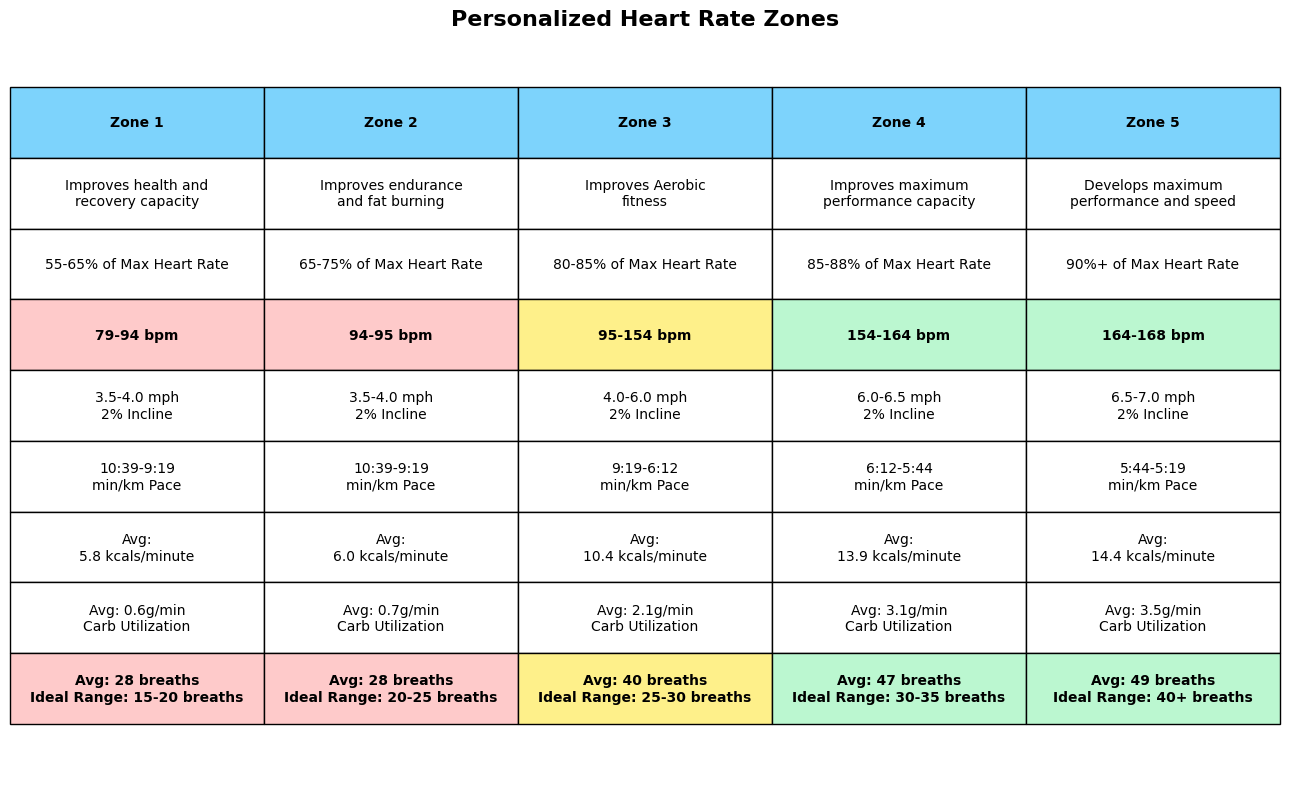

In [9]:
# Step 4: Create and display the heart rate zone table
fig, ax = create_heart_rate_zone_table_from_zones(df, zones)
plt.show()

## Alternative: Direct Zone Specification

You can also create the zone table by specifying zone boundaries directly, without using the automatic detection:

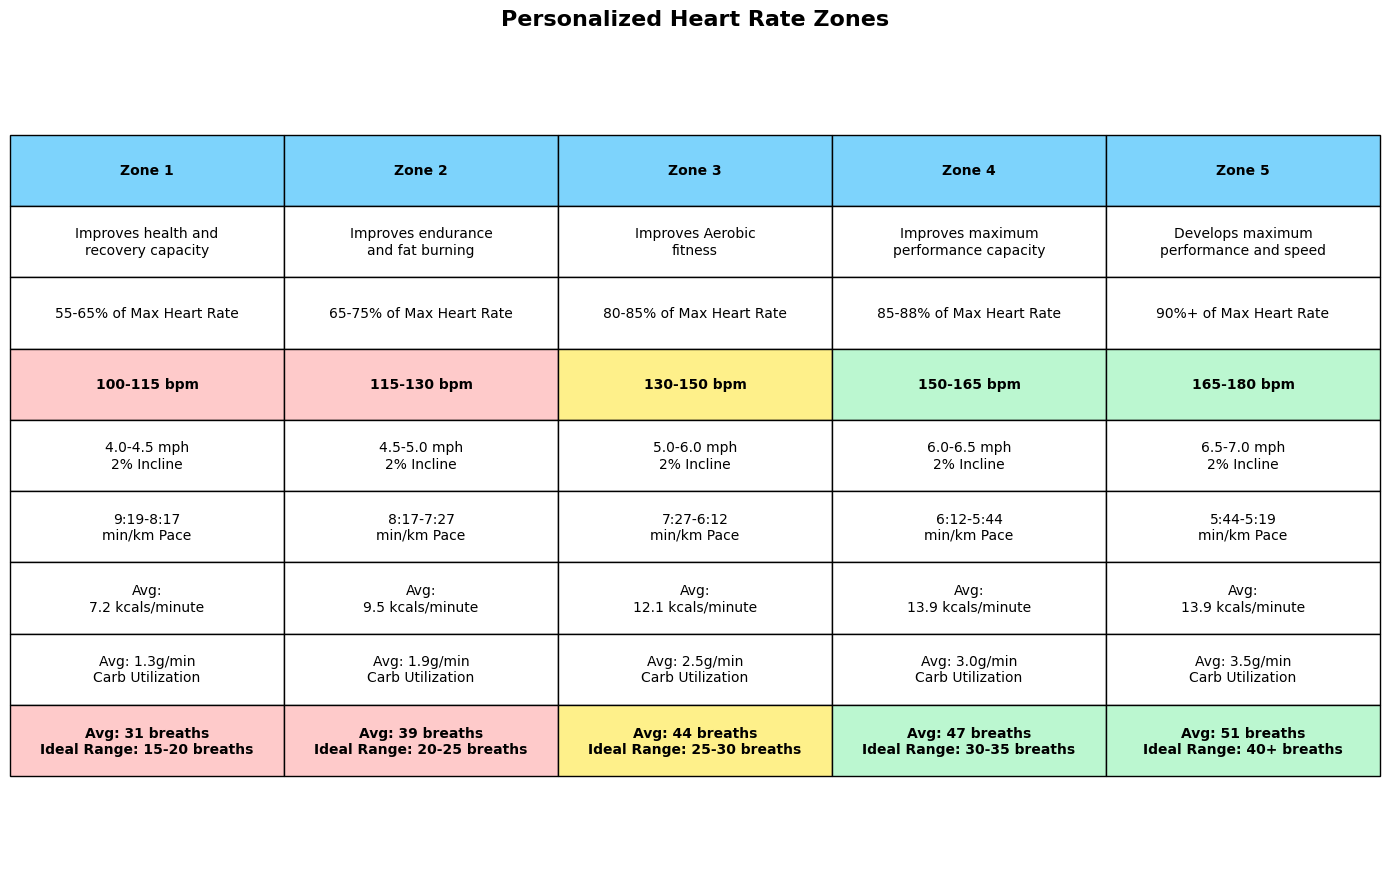

In [10]:
# Example: Create zone table with manual zone boundaries
# This is useful when you have predetermined zones or want to customize them

# Manual zone boundaries (adjust these to your needs)
manual_zone_1_start = 100  # Recovery zone start
manual_zone_2_start = 115  # Fat burning zone start  
manual_zone_3_start = 130  # Aerobic zone start (around VT1)
manual_zone_4_start = 150  # Threshold zone start (approaching VT2)
manual_zone_5_start = 165  # VO2 Max zone start (at VT2)
manual_zone_5_end = 180    # Maximum heart rate

# Create the table with manual zones
fig_manual, ax_manual = create_heart_rate_zone_table(
    df,
    zone_1_start=manual_zone_1_start,
    zone_2_start=manual_zone_2_start,
    zone_3_start=manual_zone_3_start,
    zone_4_start=manual_zone_4_start,
    zone_5_start=manual_zone_5_start,
    zone_5_end=manual_zone_5_end,
    figsize=(14, 9)
)
plt.show()